### Sloth

In [1]:
import gc
import glob
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

import dask
from dask.diagnostics import ProgressBar
from IPython.display import HTML
from tqdm import tqdm

sys.path.append('..')
from src.utils import parse_ncf_stack_filename, get_vs_number
from src.laplacian import laplacian_fiber
from src.gradiometry import temporal_fft, fdg_sloth, ifdg_stack, sloth_to_velocity, fk_peak_velocity
from src.plots import plot_sloth_section, plot_phase_velocity_section
from src.post import sloth_quality_metrics, print_quality_report

import matplotlib as mpl
mpl.rcParams["animation.html"] = "jshtml"
mpl.rcParams["animation.embed_limit"] = 200.0

old_fig_dpi = plt.rcParams['figure.dpi']
old_save_dpi = plt.rcParams['savefig.dpi']

#### 1. Load narrowband VSGs (s1 + s2)

In [2]:
# Narrowband fundamental-mode VSGs produced in vsg.ipynb (f-k isolated, saved
# to ncf_narrow). This notebook does NO preprocessing -- it loads and analyses.
NARROW = "../data/ncf_narrow/"

# Select virtual sources INDEPENDENTLY for s1 and s2. Use a (min, max) VS range
# or an explicit list of VS numbers. s1 has the higher SNR, so you may keep a
# wider VS range for s1 and a tighter one for s2 (or set VS_S2 = [] to drop s2).
VS_S1 = (20, 120)
VS_S2 = (20, 120)

def _pick(files, sel):
    keep = (lambda v: sel[0] <= v <= sel[1]) if isinstance(sel, tuple) \
        else (lambda v: v in set(sel))
    return [f for f in files if keep(get_vs_number(f))]

files_s1 = _pick(sorted(glob.glob(NARROW + "20211012_cc_*_45d_v1_s1_fk_*.npz"),
                        key=get_vs_number), VS_S1)
files_s2 = _pick(sorted(glob.glob(NARROW + "20211012_cc_*_45d_v1_s2_fk_*.npz"),
                        key=get_vs_number), VS_S2)
files = files_s1 + files_s2

print(f"s1: {len(files_s1):2d} VSGs  VS {[get_vs_number(f) for f in files_s1]}")
print(f"s2: {len(files_s2):2d} VSGs  VS {[get_vs_number(f) for f in files_s2]}")
print(f"total gathers feeding the stack: {len(files)}")
assert files, "No narrowband VSGs found -- run the narrowband section in vsg.ipynb first."

s1: 21 VSGs  VS [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120]
s2: 21 VSGs  VS [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120]
total gathers feeding the stack: 42


In [3]:
# Load ONE central VSG to walk the pipeline step by step (full window).
ncf0_path = files_s1[len(files_s1) // 2]
arc0   = np.load(ncf0_path)
data0  = arc0["data"]                  # (nch, nlag) narrowband (f-k isolated) gather
lag    = arc0["lag"]                   # (nlag,) one-sided causal lag (s)
offset = arc0["offset"]                # (nch,) signed offset; 0 at the VS
fs = 1.0 / (lag[1] - lag[0])            # Hz
dx = float(abs(offset[1] - offset[0]))  # m

# Sloth band: 3-8 Hz avoids the aperture floor (<~3 Hz) and the noisy high end.
F_MIN, F_MAX = 3.0, 8.0
# Wavenumber low-pass for the Laplacian (cycles/m). None = off; set by the
# calibration cell below (removes the high-k tail that biases the sloth slow).
K_CUTOFF = None

date0, vs0, window0, mode0 = parse_ncf_stack_filename(ncf0_path)
print(f"VS={vs0} | data {data0.shape} (nch, nlag) | fs={fs:.1f} Hz | dx={dx:.2f} m")
print(f"lag {lag[0]:.2f}..{lag[-1]:.2f} s | offset {offset.min():.0f}..{offset.max():.0f} m")

VS=070 | data (123, 450) (nch, nlag) | fs=250.0 Hz | dx=8.16 m
lag 0.00..1.80 s | offset -498..498 m


#### 2. Temporal FFT

V (123, 9) (nch, nfreq) | 9 freqs: 3.33..7.78 Hz


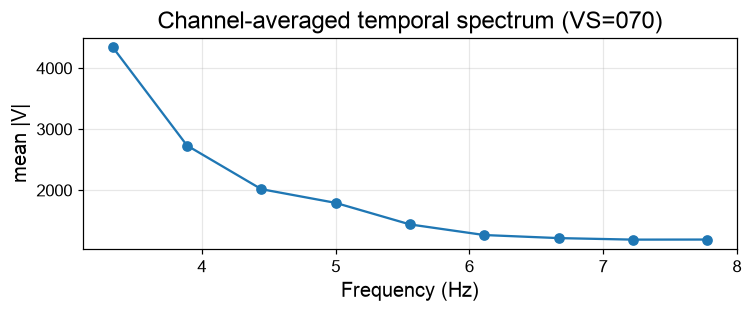

In [4]:
# Temporal FFT of the masked VSG, restricted to the band. V is (nch, nfreq)
# complex; DC is excluded so the sloth's (i*omega)^2 denominator is safe.
V, freqs = temporal_fft(data0, fs, f_min=F_MIN, f_max=F_MAX, axis=-1)
print(f"V {V.shape} (nch, nfreq) | {freqs.size} freqs: {freqs[0]:.2f}..{freqs[-1]:.2f} Hz")

plt.figure(figsize=(7, 3))
plt.plot(freqs, np.abs(V).mean(axis=0), "o-")
plt.xlabel("Frequency (Hz)"); plt.ylabel("mean |V|")
plt.title(f"Channel-averaged temporal spectrum (VS={vs0})")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

#### 3. Pseudospectral Laplacian

In [5]:
# Along-fibre pseudospectral Laplacian (mode = fiber_1d for a straight DAS
# cable): d2/dl2 via the channel-axis FFT, plus the 1/r curvature term
# (exact for an in-line virtual source). Pseudospectral -> no finite-
# difference stencil bias.
lap_V = laplacian_fiber(V, dx, offset=offset, include_curvature=True, k_cutoff=K_CUTOFF)
print(f"lap_V {lap_V.shape} (nch, nfreq) | mode=fiber_1d, curvature=on")

lap_V (123, 9) (nch, nfreq) | mode=fiber_1d, curvature=on


#### 4. Sloth: per-VSG, then position-aligned stack (s1+s2)

In [6]:
# Per-VSG sloth for the single gather above (eq. 9)
s2_single = fdg_sloth(V, lap_V, freqs, freq_axis=-1)
print(f"per-VSG sloth {s2_single.shape} (nch, nfreq), {s2_single.dtype}")

per-VSG sloth (123, 9) (nch, nfreq), complex128


In [7]:
import warnings

def _tukey(n, alpha=0.3):
    """Numpy-only Tukey (tapered-cosine) window of length n."""
    if alpha <= 0 or n < 2:
        return np.ones(max(n, 1))
    w = np.ones(n)
    e = int(np.floor(alpha * (n - 1) / 2.0))
    if e < 1:
        return w
    t = np.arange(e)
    ramp = 0.5 * (1.0 + np.cos(np.pi * (2.0 * t / (alpha * (n - 1)) - 1.0)))
    w[:e] = ramp; w[-e:] = ramp[::-1]
    return w

def stack_sloth(files, *, f_min, f_max, k_cutoff=None, r_exclude_m=150.0,
                aperture_m=350.0, channel_taper_alpha=0.3, include_curvature=True,
                stack_method='median', quality_max=1.0):
    """Per-VSG I-FDG sloth (eq. 9) -> position-aligned stack (eq. 10).
    Gathers are centred on their own VS and differ in size, so they are aligned
    on the absolute-channel grid (VS index + row - zero-offset row). s1 and s2
    gathers of the same VS land on the same positions, so passing both simply
    doubles the samples that feed the robust stack.

    aperture_m   : trim each gather to |offset| <= aperture_m before the
                   Laplacian (both limbs kept), then channel-taper the kept
                   window. ~350 m is the sweet spot here (coherence peaks, gaps 0):
                   a full limb on both sides (all truncated) and the far offsets
                   are low-SNR/scattered (high-k bias); <~250 m raises the
                   aperture floor f_min ~ 3c/aperture into the band. None keeps
                   the full window.
    channel_taper_alpha : Tukey fraction applied across channels after the
                   aperture clip so the channel-axis FFT in the pseudospectral
                   Laplacian sees no step at the trimmed edge (it assumes
                   periodicity). 0 disables.
    stack_method : 'median' (robust -- rejects nodal/outlier pixels; default)
                   or 'mean' (Davis eq. 10).
    quality_max  : if set, mask pixels where |Im/Re| of the stacked sloth (the
                   transport-equation residual) exceeds it -- a reliability flag.
    Returns (positions_m, freqs, s2, coverage), coverage = #gathers/pixel."""
    per, starts, offsets, freqs = [], [], [], None
    for f in files:
        a = np.load(f); d, lg, off = a['data'], a['lag'], a['offset']
        if aperture_m is not None:                      # trim to |offset| <= aperture_m
            keep_ap = np.abs(off) <= aperture_m
            d, off = d[keep_ap], off[keep_ap]
        if d.shape[0] < 5:                              # too few channels to differentiate
            continue
        if channel_taper_alpha:                         # taper the trimmed window
            d = d * _tukey(d.shape[0], channel_taper_alpha)[:, None]
        fs = 1.0 / (lg[1] - lg[0]); dxi = float(abs(off[1] - off[0]))
        V, fr = temporal_fft(d, fs, f_min=f_min, f_max=f_max, axis=-1)
        lapV = laplacian_fiber(V, dxi, offset=off,
                               include_curvature=include_curvature, k_cutoff=k_cutoff)
        per.append(fdg_sloth(V, lapV, fr, freq_axis=-1))
        starts.append(get_vs_number(f) - int(np.argmin(np.abs(off))))
        offsets.append(off); freqs = fr
    gmin = min(starts); gmax = max(s + p.shape[0] for s, p in zip(starts, per))
    ng, nf = gmax - gmin, freqs.size
    contrib = np.full((len(per), ng, nf), np.nan + 0j)
    for idx, (s2i, st, off) in enumerate(zip(per, starts, offsets)):
        block = np.where((np.abs(off) >= r_exclude_m)[:, None], s2i, np.nan)
        contrib[idx, st - gmin: st - gmin + s2i.shape[0], :] = block
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        if stack_method == 'median':
            s2 = np.nanmedian(contrib.real, axis=0) + 1j * np.nanmedian(contrib.imag, axis=0)
        else:
            s2 = np.nanmean(contrib, axis=0)
    coverage = np.sum(np.isfinite(contrib.real), axis=0)
    s2[coverage == 0] = np.nan
    if quality_max is not None:
        q = np.abs(s2.imag) / (np.abs(s2.real) + 1e-30)
        s2[q > quality_max] = np.nan
    dx0 = float(abs(np.load(files[0])['offset'][1] - np.load(files[0])['offset'][0]))
    positions = (gmin + np.arange(ng)) * dx0
    return positions, freqs, s2, coverage

positions, freqs_stack, s2, coverage = stack_sloth(
    files, f_min=F_MIN, f_max=F_MAX,
    aperture_m=350.0, stack_method='median', quality_max=1.0,
)
print(f"stacked sloth {s2.shape} (nx, nfreq) | s1+s2 | median | aperture<=350 m | quality<=1.0")

stacked sloth (152, 9) (nx, nfreq) | s1+s2 | median | aperture<=350 m | quality<=1.0


(<Figure size 1320x550 with 2 Axes>,
 <Axes: title={'center': 'I-FDG sloth  $\\hat{s}^2(x, f)$  (narrowband, s1+s2, median)'}, xlabel='Distance along cable (m)', ylabel='Frequency (Hz)'>)

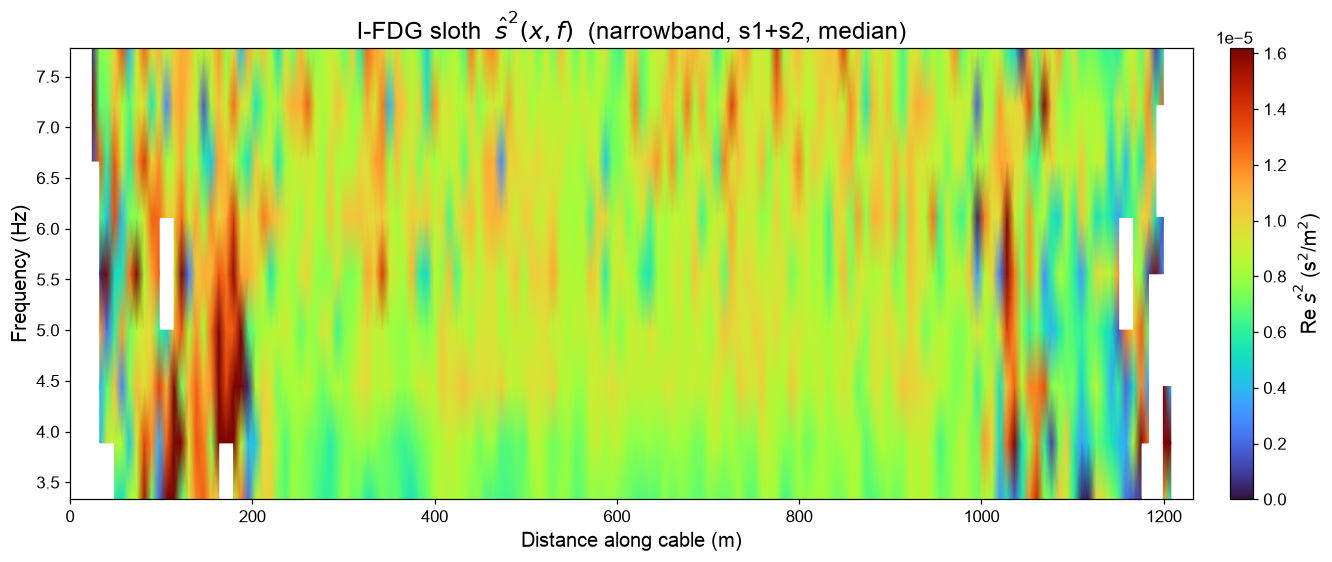

In [8]:
# Sloth panel: distance x frequency, colour = Re(sloth)  (low f at bottom)
plot_sloth_section(positions, freqs_stack, s2, invert_freq=False,
                   title=r"I-FDG sloth  $\hat{s}^2(x, f)$  (narrowband, s1+s2, median)")

(<Figure size 1320x550 with 2 Axes>,
 <Axes: title={'center': 'I-FDG phase velocity  $\\hat{V}(x, f)$  (narrowband, s1+s2, median)'}, xlabel='Distance along cable (m)', ylabel='Frequency (Hz)'>)

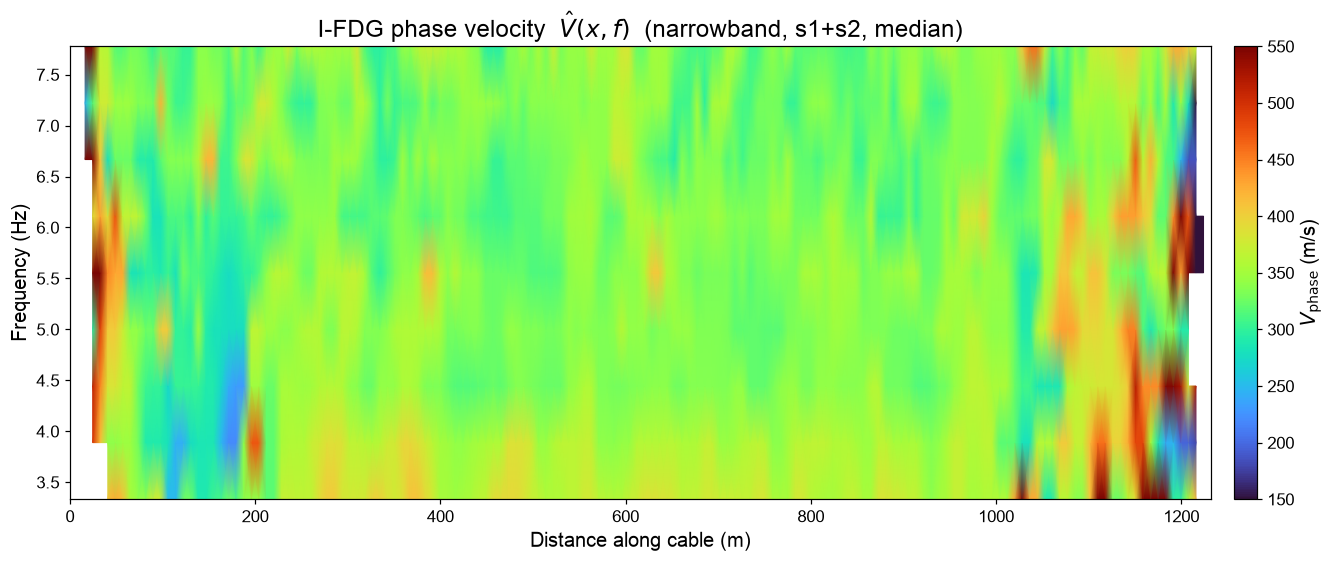

In [9]:
# Same panel as PHASE VELOCITY (m/s): show_velo converts 1/sqrt(Re sloth).
# lateral_median smooths across channels (display only); white = NaN where
# Re(sloth) <= 0 (non-physical) or rejected by the quality mask.
plot_sloth_section(
    positions, freqs_stack, s2,
    show_velo=True, unit="m", lateral_median=3,
    vmin=150, vmax=550, invert_freq=False,
    title=r"I-FDG phase velocity  $\hat{V}(x, f)$  (narrowband, s1+s2, median)",
)

#### 5. Evaluation / assessment

Quantify the stacked section rather than eyeballing it: the fraction that is
non-physical (**white %**), the robust phase-velocity centre, the **lateral
coherence** (lag-1 along-fibre autocorrelation of velocity -- the key
"real image vs. noise" number; ~0 is noise-like, ->1 is coherent), and the RMS
misfit of the gradiometry dispersion against an independent **FK-peak**
reference (an absolute-velocity sanity check).

In [10]:
# Independent FK-peak dispersion from a central s1 gather (reference velocity).
_a  = np.load(files_s1[len(files_s1) // 2])
_dt = float(np.median(np.diff(_a['lag'])))
_dx = float(np.median(np.abs(np.diff(np.sort(_a['offset'])))))
fk_freqs, fk_c = fk_peak_velocity(_a['data'], _dt, _dx, f_min=F_MIN, f_max=F_MAX, v_max=500.0)

metrics = sloth_quality_metrics(positions, freqs_stack, s2, fk_ref=(fk_freqs, fk_c),
                                coverage=coverage)
print_quality_report(metrics, freqs=freqs_stack)

I-FDG sloth - quality report
  grid                 : 152 positions x 9 freqs
  non-physical (white) : 5.9%   (lower is better)
  phase velocity       : median 340 m/s (IQR 319-364)
  lateral coherence    : +0.16   (lag-1 spatial autocorr; ~0 noise-like, ->1 coherent)
  vs FK-peak dispersion: RMS 21 m/s
  coverage             : 12.2 gathers/pixel (mean)
  coverage gaps        : 0.0% of grid uncovered (image gaps)
  non-physical (covered): 5.9% of covered pixels
  dispersion c(f):
        3.3 Hz :   367 m/s
        3.9 Hz :   358 m/s
        4.4 Hz :   335 m/s
        5.0 Hz :   338 m/s
        5.6 Hz :   336 m/s
        6.1 Hz :   329 m/s
        6.7 Hz :   331 m/s
        7.2 Hz :   335 m/s
        7.8 Hz :   338 m/s


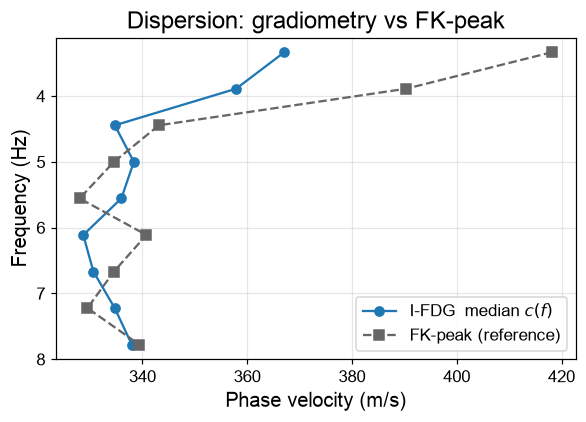

In [11]:
# Gradiometry dispersion (median across the section) vs the FK-peak reference.
order = np.argsort(fk_freqs)
cref  = np.interp(freqs_stack, fk_freqs[order], fk_c[order])
plt.figure(figsize=(5.5, 4))
plt.plot(metrics['c_of_f'], freqs_stack, 'o-', label=r'I-FDG  median $c(f)$')
plt.plot(cref, freqs_stack, 's--', color='0.4', label='FK-peak (reference)')
plt.xlabel('Phase velocity (m/s)'); plt.ylabel('Frequency (Hz)')
plt.gca().invert_yaxis(); plt.grid(alpha=0.3); plt.legend()
plt.title('Dispersion: gradiometry vs FK-peak'); plt.tight_layout(); plt.show()

In [12]:
# Aperture trade-off (data-dependent): a tighter aperture cuts high-k noise but,
# with sparse virtual sources, can open coverage gaps. Sweep it on THIS dataset
# and pick the smallest aperture that keeps coverage gaps ~0% while giving the
# best lateral coherence / lowest non-physical %.
print(f"{'aperture':>9} | {'gaps%':>6} {'nonphys%':>9} {'cov':>4} {'coh':>6} {'median c':>9}")
for _ap in [200.0, 250.0, 300.0, 350.0, 400.0, 500.0]:
    _p, _fr, _s2, _cov = stack_sloth(files, f_min=F_MIN, f_max=F_MAX,
                                     aperture_m=_ap, stack_method='median', quality_max=1.0)
    _m = sloth_quality_metrics(_p, _fr, _s2, coverage=_cov)
    print(f"{_ap:8.0f}m | {_m['uncovered_pct']:6.1f} {_m['nonphysical_pct']:9.1f} "
          f"{_m['coverage_mean']:4.1f} {_m['lateral_coherence']:+6.2f} {_m['median_c']:8.0f}")

 aperture |  gaps%  nonphys%  cov    coh  median c
     200m |    0.0      37.5  3.4  -0.15      373
     250m |    0.0       9.5  6.5  +0.02      352
     300m |    0.0       7.0  9.4  +0.09      344
     350m |    0.0       5.9 12.2  +0.16      340
     400m |    0.0       5.0 15.3  +0.15      338
     500m |    0.0       5.3 19.9  +0.14      338


#### 6. Save the dispersion product (for inversion)

Write the phase-velocity section `c(x, f)` (plus the complex sloth and a per-channel quality flag) to `results/`, so `inv.ipynb` can invert the section-median dispersion without recomputing the stack.

In [13]:
from src.post import save_products

# Phase velocity (m/s) from the stacked sloth; clip to the physical window.
_re = np.real(s2)
vel = np.full(s2.shape, np.nan)
vel[_re > 0] = 1.0 / np.sqrt(_re[_re > 0])
vel[(vel < 120) | (vel > 900)] = np.nan
valid = np.isfinite(vel).any(axis=1)            # channels with any physical velocity

save_products(
    "../results/gradiometry_dispersion.npz",
    s2=s2, vel=vel, freqs=freqs_stack, positions=positions, valid=valid,
    meta={"date": "20211012", "band": "235_487", "sources": "s1+s2",
          "aperture_m": 350, "vs_range": "20-120", "stack": "median", "quality_max": 1.0},
)
print("saved -> ../results/gradiometry_dispersion.npz  (feeds inv.ipynb)")

saved -> ../results/gradiometry_dispersion.npz  (feeds inv.ipynb)
